In [1]:
import pandas as pd 
pd.options.mode.chained_assignment = None  # default='warn'
import glob 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns 
import numpy as np 
import os
import scipy.stats
from scipy.spatial.distance import jensenshannon
import sys


from config import home_path, supp_table_path, llm_review_path

sys.path.insert(1, home_path) 
from common_functions import (
    my_colors, 
    format_p, 
    get_pfam_info, 
    mean_confidence_interval, 
    sort_dict_by_key, 
    sort_dict_by_value,
    three_letter_to_one_letter,
    entropy,
    p_val_to_stars
)
import pickle 
import json

figure_path = llm_review_path + "high_res_figures/length_figure/clinvar_misclassification/"
def save_figure(fig, name, root_path = figure_path, save_svg = True):
    fig.savefig(root_path + name + ".png", bbox_inches = "tight")
    if save_svg:
        fig.savefig(root_path + name + ".svg", format="svg", dpi = 1200, bbox_inches = "tight")
 
regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']
def augment_masked_df_with_site_entropy(df, limit_normal_aas = True, return_entropy = True):
    df["name"] = df["ref_aa"] + df["aa_pos"].astype(str) + df["token_str"]
    df = df.loc[df["token_str"].isin(regular_aas)]
    variant_to_s1 = {}
    variant_to_adj_prob = {}
    variant_to_site_entropy = {}
    for pos, sub_df in df.groupby("aa_pos"):
        v_to_adj_score = {}
        valid_prob_total = np.sum(sub_df["score"])
        for index, row in sub_df.iterrows():
            v_to_adj_score[row["name"]] = row["score"] / valid_prob_total
        
        sub_df["adj_score"] = sub_df["name"].apply(lambda x : v_to_adj_score[x])
        
        wt_val = sub_df.loc[sub_df["ref_aa"] == sub_df["token_str"]]
        assert len(wt_val) == 1
        wt_score = wt_val.iloc[0]["adj_score"]
        
        adj_prob_list = []
        for index, row in sub_df.iterrows():
            variant_to_s1[row["name"]] = np.log(row["adj_score"]) - np.log(wt_score)
            variant_to_adj_prob[row["name"]] = row["adj_score"] / valid_prob_total
            adj_prob_list.append(row["adj_score"] / valid_prob_total)
        ent_val = entropy(adj_prob_list)
        
        for name in sub_df["name"].values: variant_to_site_entropy[name] = ent_val

    if return_entropy:
        df["site_entropy"] = df["name"].apply(lambda x : variant_to_site_entropy[x])
            
    df["s1"] = df["name"].apply(lambda x : variant_to_s1[x])
    df["adj_score"] = df["name"].apply(lambda x : variant_to_adj_prob[x])
    
    df = df.set_index("name")
    return df


/Genomics/argo/users/jf9645/miniconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
models = ["esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B"]
model_to_display_name = {
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" : "ESM-2 (35M)",
    "esm_2_150M" : "ESM-2 (150M)",
    "esm_2_650M" : "ESM-2 (650M)",
    "esm_2" : "ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)",
}

human_data = pd.read_csv(llm_review_path + "data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")

In [3]:
summary_res_path = "./gene_entropy_summaries_4000/"

summary_res_path_control = "./summary_results_control_short_sequences/"


model_to_average_site_entropy = {m : {} for m in models}
model_to_correct_aa_by_pos = {m : {} for m in models}

genes_in_data = glob.glob("./masked_results_human_proteome_forced_long_rotary_under_4000/esm_2/*.csv.gz")

genes_in_data = list(
    map(
        lambda x : x.replace("./masked_results_human_proteome_forced_long_rotary_under_4000/esm_2/", "").replace(".csv.gz", ""),
        genes_in_data
    )
)

with open(summary_res_path + "esm_2_4000.json", "r") as f:
    data = json.load(f)
f.close()

protein_to_length = {k : v["gene_length"] for (k,v) in data.items()}



In [4]:
rotary_model_to_df = {}

model_to_average_site_entropy_control = {}
model_to_correct_aa_by_pos_control = {}



for m in models:
    
    counter_2000 = 0 
    counter_3000 = 0 
    with open(summary_res_path + m + "_4000.json", "r") as f:
        data = json.load(f)
    f.close()
    
    pos_to_entropy_vals_2000_3000 = {}
    pos_to_correct_2000_3000 = {}

    pos_to_entropy_vals_over_3000 = {}
    pos_to_correct_over_3000 = {}

    for k, v in data.items():
        
        if (v["gene_length"] <= 3000) and (v["gene_length"] > 2000):
            counter_2000 += 1
            for k2, v2 in v["positional_entropy"].items():
                if k2 in pos_to_entropy_vals_2000_3000.keys():
                    pos_to_entropy_vals_2000_3000[k2].append(v2)
                else:
                    pos_to_entropy_vals_2000_3000[k2] = [v2]
                    
            
            for k2, v2 in v["positional_correct_aa"].items():
                if k2 in pos_to_correct_2000_3000.keys():
                    pos_to_correct_2000_3000[k2].append(v2)
                else:
                    pos_to_correct_2000_3000[k2] = [v2]
                    
  
                    
        if v["gene_length"] > 3000:
            counter_3000 += 1
            for k2, v2 in v["positional_entropy"].items():
                if k2 in pos_to_entropy_vals_over_3000.keys():
                    pos_to_entropy_vals_over_3000[k2].append(v2)
                else:
                    pos_to_entropy_vals_over_3000[k2] = [v2]
                    
            
            for k2, v2 in v["positional_correct_aa"].items():
                if k2 in pos_to_correct_over_3000.keys():
                    pos_to_correct_over_3000[k2].append(v2)
                else:
                    pos_to_correct_over_3000[k2] = [v2]
        
        
    pos_to_mean_entropy_2000_3000 = {int(k) : np.mean(v) for (k,v) in pos_to_entropy_vals_2000_3000.items()}
    pos_to_correct_rate_2000_3000 = {int(k) : np.mean(v) for (k,v) in pos_to_correct_2000_3000.items()}
    
    pos_to_mean_entropy_over_3000 = {int(k) : np.mean(v) for (k,v) in pos_to_entropy_vals_over_3000.items()}
    pos_to_correct_rate_over_3000 = {int(k) : np.mean(v) for (k,v) in pos_to_correct_over_3000.items()}
    
    
    with open(summary_res_path_control + m + "_summary_results.json", "r") as f:
        data = json.load(f)
    f.close()
    
    print(data.keys(), counter_2000, counter_3000, len(data["entropy"]), len(data["entropy"]["1"].keys()), list(data["entropy"]["1"].keys())[:10]) 
    
    dfx = human_data.loc[human_data["Entry Name"].isin(list(data["entropy"]["1"].keys()))]
    
    print(np.min(dfx["Length"].values), np.max(dfx["Length"].values))
    
    ent_compiled_res = {}
    accuracy_compiled_res = {}
    
    ent_data = data["entropy"]
    accuracy_data = data["correct_aa"]
    
    for position, pos_data in ent_data.items():
        position = int(position)
        
        mean_val = np.mean(list(pos_data.values()))
        ent_compiled_res[position] = mean_val
        
    print(len(ent_data["4"].values()))
        
    model_to_average_site_entropy_control[m] = ent_compiled_res
    
    
    for position, pos_data in accuracy_data.items():
        position = int(position)  
        total_accuracy = np.sum(list(pos_data.values())) / len(pos_data)
        accuracy_compiled_res[position] = total_accuracy
        

    
    
    dfc = pd.DataFrame(
        {
            "rotary_correct_rate_2000_3000" : pos_to_correct_rate_2000_3000,
            "rotary_mean_entropy_2000_3000" : pos_to_mean_entropy_2000_3000,
            "rotary_correct_rate_over_3000" : pos_to_correct_rate_over_3000,
            "rotary_mean_entropy_over_3000" : pos_to_mean_entropy_over_3000,   
            "correct_rate_short_control" : accuracy_compiled_res,
            "mean_entropy_short_control" : ent_compiled_res
        }
    )
    rotary_model_to_df[m] = dfc
    model_to_correct_aa_by_pos_control[m] = accuracy_compiled_res
    

    
print(len(ent_data["4"].values()), counter_2000, counter_3000)
for m in models:
    fn = f"{home_path}clinvar/nlp_review_misclassification/f_results_all/summary_stats_{m}.csv"
    dfo = pd.read_csv(fn)

    long_protein_json_path = home_path + "clinvar/nlp_review_misclassification/g_results_all/weighted_entropies_" + m + ".json"

    with open(long_protein_json_path, "r") as f1:
        data = json.load(f1)
    f1.close()


    tiled_site_entropy_2000_3000 = {}
    tiled_site_entropy_over_3000 = {}

    for protein in genes_in_data:
        
        protein_length = protein_to_length[protein]
        weighted_entropies = data[protein]["weighted_entropies"]
        if protein_length < 3000 and protein_length >= 2000:
            for k, v in weighted_entropies.items():
                k = int(k)
                if k in tiled_site_entropy_2000_3000.keys():
                    tiled_site_entropy_2000_3000[k].append(v)
                else:
                    tiled_site_entropy_2000_3000[k] = [v]
                    
        if protein_length >= 3000:
            for k, v in weighted_entropies.items():
                k = int(k)
                if k in tiled_site_entropy_over_3000.keys():
                    tiled_site_entropy_over_3000[k].append(v)
                else:
                    tiled_site_entropy_over_3000[k] = [v]
                    
                    
    pos_to_mean_entropy_2000_3000_tiled = {int(k) : np.mean(v) for (k,v) in tiled_site_entropy_2000_3000.items()}
    pos_to_mean_entropy_over_3000_tiled = {int(k) : np.mean(v) for (k,v) in tiled_site_entropy_over_3000.items()}
    dfc = rotary_model_to_df[m]
    dfc["tiled_mean_entropy_2000_3000"] = pos_to_mean_entropy_2000_3000_tiled
    dfc["tiled_mean_entropy_over_3000"] = pos_to_mean_entropy_over_3000_tiled
    rotary_model_to_df[m] = dfc
            
    

dict_keys(['entropy', 'correct_aa']) 299 77 1021 100 ['RAB44_HUMAN', 'IGSF2_HUMAN', 'EPHB6_HUMAN', 'S12A3_HUMAN', 'L2GL2_HUMAN', 'AT1A2_HUMAN', 'GCSP_HUMAN', 'RPGR_HUMAN', 'CO6A2_HUMAN', 'TGRM2_HUMAN']
1001 1021
100
dict_keys(['entropy', 'correct_aa']) 299 77 1021 100 ['RAB44_HUMAN', 'IGSF2_HUMAN', 'EPHB6_HUMAN', 'S12A3_HUMAN', 'L2GL2_HUMAN', 'AT1A2_HUMAN', 'GCSP_HUMAN', 'RPGR_HUMAN', 'CO6A2_HUMAN', 'TGRM2_HUMAN']
1001 1021
100
dict_keys(['entropy', 'correct_aa']) 299 77 1021 100 ['RAB44_HUMAN', 'IGSF2_HUMAN', 'EPHB6_HUMAN', 'S12A3_HUMAN', 'L2GL2_HUMAN', 'AT1A2_HUMAN', 'GCSP_HUMAN', 'RPGR_HUMAN', 'CO6A2_HUMAN', 'TGRM2_HUMAN']
1001 1021
100
dict_keys(['entropy', 'correct_aa']) 299 77 1021 100 ['RAB44_HUMAN', 'IGSF2_HUMAN', 'EPHB6_HUMAN', 'S12A3_HUMAN', 'L2GL2_HUMAN', 'AT1A2_HUMAN', 'GCSP_HUMAN', 'RPGR_HUMAN', 'CO6A2_HUMAN', 'TGRM2_HUMAN']
1001 1021
100
dict_keys(['entropy', 'correct_aa']) 299 77 1021 100 ['RAB44_HUMAN', 'IGSF2_HUMAN', 'EPHB6_HUMAN', 'S12A3_HUMAN', 'L2GL2_HUMAN', 'AT1A2_

--------------------------
esm_2_8M
3.6118429172857534 1000
3.754766718430258 1000
3.898200076820862 1000
2.152817053845366e-118
2.0238447438360527e-159
4.436004373470969e-165
--------------------------
esm_2_35M
3.3022148262430964 1000
3.6804634110876053 1000
3.7913981102010954 1000
2.2250195581023976e-165
3.2577164227386996e-142
1.6629295594672565e-165
--------------------------
esm_2_150M
2.9590653445927972 1000
3.27992169282617 1000
3.369803573896518 1000
1.4101932907564001e-164
1.746281212760807e-92
7.340048818009237e-165
--------------------------
esm_2_650M
2.365949409007089 1000
2.6697685500605495 1000
2.8946916520967925 1000
2.3553441410882082e-160
2.2665341057391086e-161
2.5088115400258435e-165
--------------------------
esm_2
1.8628407377413378 1000
2.0414675657293873 1000
2.2650216989817964 1000
3.7798504660164674e-140
1.5839695779269193e-156
2.0747638169471697e-164
--------------------------
esm_2_15B
1.4164123410053115 1000
1.5737115046443746 1000
1.7386495318904853 1000


/tmp/ipykernel_1105412/3139350546.py:46: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
/tmp/ipykernel_1105412/3139350546.py:46: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
/tmp/ipykernel_1105412/3139350546.py:46: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
/tmp/ipykernel_1105412/3139350546.py:46: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
/tmp/ipykernel_1105412/3

Text(0.5, 1.1, 'Untiled Long Proteins')

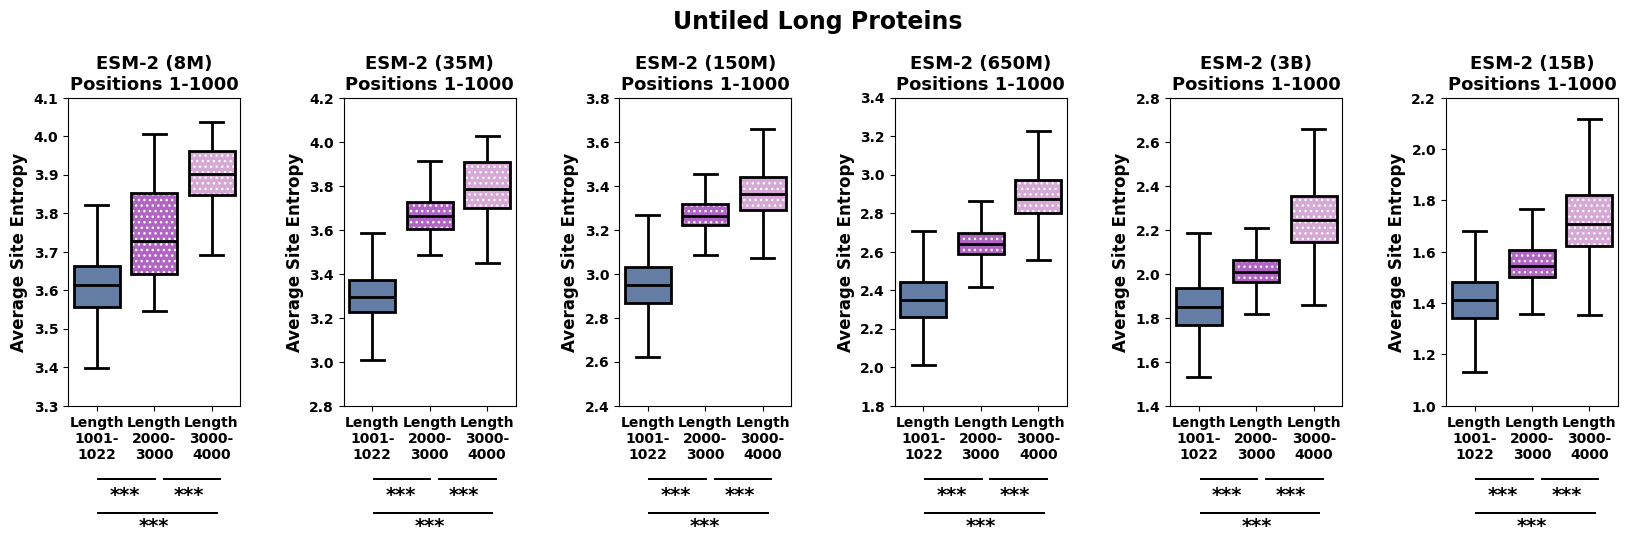

In [5]:
fig, axes = plt.subplots(1,6,figsize = (20, 4))
axes = axes.ravel()
fig.subplots_adjust(wspace = 0.6)


esm_2_models = ["esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B"]


y_ticks = [1.0,1.5,2.0,2.5,3.0,3.5,4.0,round(np.log2(20), 2)]

for i, m in enumerate(esm_2_models):
    print("--------------------------")
    
    ax = axes[i]

    dfc = rotary_model_to_df[m]
    sub_df = dfc.loc[dfc.index <= 1000].sort_index() 
    
    data = [
        sub_df["mean_entropy_short_control"].values,
        sub_df["rotary_mean_entropy_2000_3000"].values,
        sub_df["rotary_mean_entropy_over_3000"].values # limited these results to be less than 4000 as well
    ]
    
    print(m)
    print(np.mean(sub_df["mean_entropy_short_control"].values), len(sub_df["mean_entropy_short_control"].values))
    print(np.mean(sub_df["rotary_mean_entropy_2000_3000"].values), len(sub_df["rotary_mean_entropy_2000_3000"].values))
    print(np.mean(sub_df["rotary_mean_entropy_over_3000"].values), len(sub_df["rotary_mean_entropy_over_3000"].values)) 

    sns.boxplot(
        data, 
        showfliers = False, 
        ax = ax,
        palette = {
            0 : "#587bb0",
            1: "mediumorchid",
            2 : "plum"
        },
        boxprops = {"edgecolor" : "black", "linewidth": 2},
        medianprops = {"color" : "black", "linewidth": 2},
        whiskerprops = {"color" : "black", "linewidth": 2},
        capprops = {"color" : "black", "linewidth": 2}, 
    )


    ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
    ax.set_title(model_to_display_name[m] + "\nPositions 1-1000", fontweight = "bold", fontsize = 13)
    ax.set_ylabel("Average Site Entropy", fontweight = "bold", fontsize = 12)
    
    hatch_list = ["", "...", "..."]
    c_list = ["white", "white", "white"]
    patches = ax.patches
    for i, (patch, hatch) in enumerate(zip(patches, hatch_list)):
        patch.set_hatch(hatch)
        patch._hatch_color = mcolors.to_rgba(c_list[i])
        
#     ax.set_yticks(y_ticks)
    



    _, p1 = scipy.stats.wilcoxon(data[0], data[1], alternative = "less")
    stars_1 = p_val_to_stars(p1)
    fs1 = 12 if stars_1 == "ns" else 14
    print(p1)

    ax.text(0.33, -0.31, stars_1, fontsize = fs1, fontweight = "bold", transform = ax.transAxes, horizontalalignment="center")
    rect = mpatches.Rectangle((0.17, -0.24), 0.34, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)

    ###########################
    rect = mpatches.Rectangle((0.55, -0.24), 0.34, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)

    _, p2 = scipy.stats.wilcoxon(data[1], data[2], alternative = "less")
    stars_2 = p_val_to_stars(p2)
    fs2 = 12 if stars_2 == "ns" else 14
    print(p2)

    ax.text(0.7, -0.31, stars_2, fontsize = fs2, fontweight = "bold", transform = ax.transAxes, horizontalalignment="center")

    ###########################
    rect = mpatches.Rectangle((0.17, -0.35), 0.7, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)

    _, p3 = scipy.stats.wilcoxon(data[0], data[2], alternative = "less")
    stars_3 = p_val_to_stars(p3)
    fs3 = 12 if stars_3 == "ns" else 14
    print(p3)

    ax.text(0.5, -0.41, stars_3, fontsize = fs3, transform = ax.transAxes, fontweight = "bold",  horizontalalignment="center")
    
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
    
fig.suptitle("Untiled Long Proteins", fontsize = 17, y = 1.1, fontweight = "bold")

------------------
esm_2_8M
3.6118429172857534
3.589276064979905
3.5234140561083325
0.9999999998977385
1.0
1.0
------------------
esm_2_35M
3.3022148262430964
3.388682370805762
3.360663260909915
7.073390406190408e-79
0.9999999999999999
7.15688069640124e-30
------------------
esm_2_150M
2.9590653445927972
3.175404624464917
3.1825219037251786
1.4359562990664876e-154
0.08137761284009809
4.3751966106286396e-144
------------------
esm_2_650M
2.365949409007089
2.53516342217015
2.6680928867000233
1.7011764338938293e-120
1.2074589444665992e-119
1.4023533578178477e-153
------------------
esm_2
1.8628407377413378
1.9415730374401665
2.081289300198691
6.592871295284246e-58
8.03778429749572e-105
4.515992718194532e-134
------------------
esm_2_15B
1.4164123410053115
1.478615326128091
1.558015372457705
1.3388555152238171e-46
1.836996810860328e-49
1.7484167824819056e-115


/tmp/ipykernel_2763152/1995044490.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
/tmp/ipykernel_2763152/1995044490.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
/tmp/ipykernel_2763152/1995044490.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
/tmp/ipykernel_2763152/1995044490.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
/tmp/ipykernel_2763152/1

Text(0.5, 1.1, 'Tiled Long Proteins')

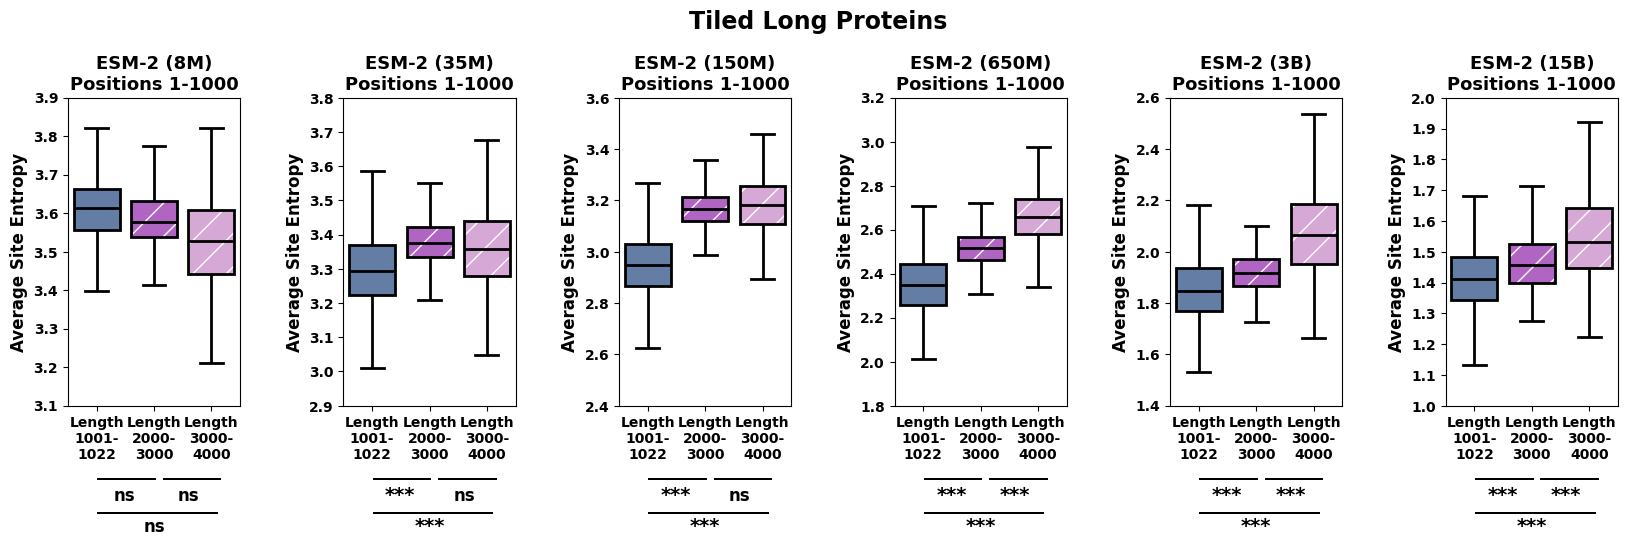

In [48]:
fig, axes = plt.subplots(1,6,figsize = (20, 4))
axes = axes.ravel()
fig.subplots_adjust(wspace = 0.6)


esm_2_models = ["esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B"]

for i, m in enumerate(esm_2_models):
    print("------------------")
   
    
    
    ax = axes[i]

    dfc = rotary_model_to_df[m]
    sub_df = dfc.loc[dfc.index <= 1000].sort_index() 
    
    data = [
        sub_df["mean_entropy_short_control"].values,
        sub_df["tiled_mean_entropy_2000_3000"].values,
        sub_df["tiled_mean_entropy_over_3000"].values
    ]
    
    print(m)
    print(np.mean(sub_df["mean_entropy_short_control"].values))
    print(np.mean(sub_df["tiled_mean_entropy_2000_3000"].values))
    print(np.mean(sub_df["tiled_mean_entropy_over_3000"].values))

    sns.boxplot(
        data, 
        showfliers = False, 
        ax = ax,
        palette = {
            0 : "#587bb0",
            1: "mediumorchid",
            2 : "plum"
        },
        boxprops = {"edgecolor" : "black", "linewidth": 2},
        medianprops = {"color" : "black", "linewidth": 2},
        whiskerprops = {"color" : "black", "linewidth": 2},
        capprops = {"color" : "black", "linewidth": 2}, 
    )


    ax.set_xticklabels(["Length\n1001-\n1022", "Length\n2000-\n3000", "Length\n3000-\n4000"], fontweight = "bold", fontsize = 10)
    ax.set_title(model_to_display_name[m] + "\nPositions 1-1000", fontweight = "bold", fontsize = 13)
    ax.set_ylabel("Average Site Entropy", fontweight = "bold", fontsize = 12)
    
    hatch_list = ["", "/", "/"]
    c_list = ["white", "white", "white"]
    patches = ax.patches
    for i, (patch, hatch) in enumerate(zip(patches, hatch_list)):
        patch.set_hatch(hatch)
        patch._hatch_color = mcolors.to_rgba(c_list[i])


    _, p1 = scipy.stats.wilcoxon(data[0], data[1], alternative = "less")
    stars_1 = p_val_to_stars(p1)
    fs1 = 12 if stars_1 == "ns" else 14
    print(p1)

    ax.text(0.33, -0.31, stars_1, fontsize = fs1, transform = ax.transAxes, fontweight = "bold", horizontalalignment="center")
    rect = mpatches.Rectangle((0.17, -0.24), 0.34, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)

    ###########################
    rect = mpatches.Rectangle((0.55, -0.24), 0.34, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)

    _, p2 = scipy.stats.wilcoxon(data[1], data[2], alternative = "less")
    stars_2 = p_val_to_stars(p2)
    fs2 = 12 if stars_2 == "ns" else 14
    print(p2)

    ax.text(0.7, -0.31, stars_2, fontsize = fs2, transform = ax.transAxes, fontweight = "bold", horizontalalignment="center")

    ###########################
    rect = mpatches.Rectangle((0.17, -0.35), 0.7, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)

    _, p3 = scipy.stats.wilcoxon(data[0], data[2], alternative = "less")
    stars_3 = p_val_to_stars(p3)
    fs3 = 12 if stars_3 == "ns" else 14
    print(p3)

    ax.text(0.5, -0.41, stars_3, fontsize = fs3, transform = ax.transAxes, fontweight = "bold", horizontalalignment="center")
    
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
    
fig.suptitle("Tiled Long Proteins", fontsize = 17, fontweight = "bold", y = 1.1)

In [62]:
# make table for data underlying above boxplots 


table_pieces = []

esm_2_models = ["esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B"]

for i, m in enumerate(esm_2_models):
    
    dfc = rotary_model_to_df[m]
    
    sub_df = dfc.loc[dfc.index <= 1000].sort_index() 
    sub_df["Model"] = model_to_display_name[m]

    sub_df["aa_position"] = list(sub_df.index)

    col_renames =  {
        "mean_entropy_short_control" : "mean_positional_entropy_length_1000_to_1022",
        "rotary_mean_entropy_2000_3000" : "mean_positional_entropy_proteins_length_2000_to_3000_rotary",
        "rotary_mean_entropy_over_3000" : "mean_positional_entropy_proteins_length_3000_to_4000_rotary",
        "tiled_mean_entropy_2000_3000" : "mean_positional_entropy_proteins_length_2000_to_3000_tiled",
        "tiled_mean_entropy_over_3000" : "mean_positional_entropy_proteins_length_3000_to_4000_tiled"

    }

    sub_df = sub_df.rename(columns = col_renames)
    sub_df = sub_df[["Model", "aa_position"] + list(col_renames.values())]


    table_pieces.append(sub_df)
    
table_out = pd.concat(table_pieces)

table_out.to_csv(supp_table_path + "positional_entropies_1_through_1000_tiled_and_rotary.csv")

In [26]:
m = "esm_2_650M"

with open(summary_res_path + m + "_4000.json", "r") as f:
    data = json.load(f)
f.close()
    
pos_to_entropy_vals_2000_3000 = {}
pos_to_correct_2000_3000 = {}

pos_to_entropy_vals_over_3000 = {}
pos_to_correct_over_3000 = {}

rotary_gene_ent_2000_3000 = []
rotary_gene_ent_over_3000 = []

gene_counter = 0
length_tracker = []
for k, v in data.items():
    if (v["gene_length"] < 3000) and (v["gene_length"] >= 2000):
        pos_ent_list = list(v["positional_entropy"].values())
        rotary_gene_ent_2000_3000.append(np.mean(pos_ent_list))
        gene_counter += 1
        length_tracker.append(v["gene_length"])

    if v["gene_length"] >= 3000:
        pos_ent_list = list(v["positional_entropy"].values())
        rotary_gene_ent_over_3000.append(np.mean(pos_ent_list))
        gene_counter += 1
        length_tracker.append(v["gene_length"])
        
long_protein_json_path = home_path + "clinvar/nlp_review_misclassification/g_results_all/weighted_entropies_" + m + ".json"

with open(long_protein_json_path, "r") as f1:
    long_protein_data = json.load(f1)
f1.close()


tiled_long_protein_average_ent = []

for gene in data.keys():
    ent_vals = long_protein_data[gene]["weighted_entropies"]
    tiled_long_protein_average_ent.append(np.mean(list(ent_vals.values())))


with open("./gene_summary_average_entropy/" + m + ".json", "r") as f:
    gene_data = json.load(f)
f.close()

control_short_average_ent =  list(gene_data["control_short"].values())

data = [
    control_short_average_ent,
    tiled_long_protein_average_ent,
    rotary_gene_ent_2000_3000 + rotary_gene_ent_over_3000
]

0.0029758384446038765
0.0014121325466438948
1.8483613466982907e-06


/tmp/ipykernel_2763152/568524045.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Short\nProteins", "Long\nProteins\nTiled", "Long\nProteins\nUntiled"],fontsize = 11, fontweight = "bold",)


Text(0.5, -0.38, '***')

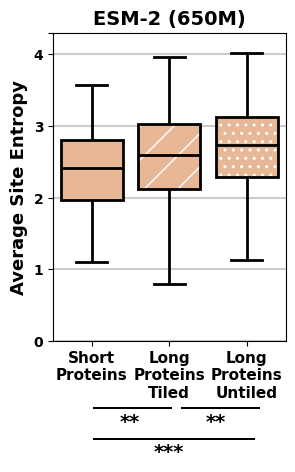

In [47]:
fig, ax = plt.subplots(figsize = (3,4))
sns.boxplot(
    data, 
    showfliers = False, 
    ax = ax,
    palette = {
        0 : "#f5b489",
        1: "#f5b489",
        2 : "#f5b489"
    },
    boxprops = {"edgecolor" : "black", "linewidth": 2},
    medianprops = {"color" : "black", "linewidth": 2},
    whiskerprops = {"color" : "black", "linewidth": 2},
    capprops = {"color" : "black", "linewidth": 2}, 
    zorder = 100
)
ax.set_yticks([0,1,2,3, 4, 4.3])
ax.set_yticklabels(["0", "1","2","3","4", ""], fontweight = "bold")
ax.set_ylabel("Average Site Entropy",  fontweight = "bold",fontsize = 13)
ax.set_title(model_to_display_name[m], fontweight = "bold", fontsize = 14)

ax.set_xticklabels(["Short\nProteins", "Long\nProteins\nTiled", "Long\nProteins\nUntiled"],fontsize = 11, fontweight = "bold",)


for y_val in ax.get_yticks():
    ax.axhline(y = y_val, color = "black", alpha = 0.2, zorder = 1)

hatch_list = ["", "/", ".."]
c_list = ["white", "white", "white"]
patches = ax.patches
for i, (patch, hatch) in enumerate(zip(patches, hatch_list)):
    patch.set_hatch(hatch)
    patch._hatch_color = mcolors.to_rgba(c_list[i])

    
_, p1 = scipy.stats.mannwhitneyu(data[0], data[1], alternative = "less")
stars_1 = p_val_to_stars(p1)
fs1 = 12 if stars_1 == "ns" else 14
print(p1)

ax.text(0.33, -0.28, stars_1, fontsize = fs1, transform = ax.transAxes, fontweight = "bold",  horizontalalignment="center")
rect = mpatches.Rectangle((0.17, -0.22), 0.34, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
ax.add_patch(rect)

###########################
rect = mpatches.Rectangle((0.55, -0.22), 0.34, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
ax.add_patch(rect)

_, p2 = scipy.stats.mannwhitneyu(data[1], data[2], alternative = "less")
stars_2 = p_val_to_stars(p2)
fs2 = 12 if stars_2 == "ns" else 14
print(p2)

ax.text(0.7, -0.28, stars_2, fontsize = fs2, transform = ax.transAxes, fontweight = "bold", horizontalalignment="center")

###########################
rect = mpatches.Rectangle((0.17, -0.32), 0.7, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
ax.add_patch(rect)

_, p3 = scipy.stats.mannwhitneyu(data[0], data[2], alternative = "less")
stars_3 = p_val_to_stars(p3)
fs3 = 12 if stars_3 == "ns" else 14
print(p3)

ax.text(0.5, -0.38, stars_3, fontsize = fs3, transform = ax.transAxes, fontweight = "bold", horizontalalignment="center")

############### esm_2_8M ############
mean  3.615025526384625
mean  3.5764801363171044
mean  3.781632782627632
0.1982513963622295
1.6658526109154131e-16
1.7519466046077943e-10
############### esm_2_35M ############


/tmp/ipykernel_2763152/1554033533.py:87: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Short\nProteins", "Long\nProteins\nTiled", "Long\nProteins\nUntiled"], fontsize = 9, fontweight = "bold")


mean  3.3072023718096166
mean  3.3833240647604845
mean  3.7171239637750335
0.00046559461974301857
3.72938589694168e-31
6.792446890444517e-24
############### esm_2_150M ############


/tmp/ipykernel_2763152/1554033533.py:87: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Short\nProteins", "Long\nProteins\nTiled", "Long\nProteins\nUntiled"], fontsize = 9, fontweight = "bold")


mean  2.9649921908462926
mean  3.1662304914282218
mean  3.2862138453535303
9.201684633515292e-07
0.00018159960668950157
4.1539078108489854e-12
############### esm_2 ############


/tmp/ipykernel_2763152/1554033533.py:87: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Short\nProteins", "Long\nProteins\nTiled", "Long\nProteins\nUntiled"], fontsize = 9, fontweight = "bold")


mean  1.868419378935354
mean  1.994892192226837
mean  2.0927600185759574
0.0786081337516653
0.038879915778922955
0.005536375676728411
############### esm_2_15B ############


/tmp/ipykernel_2763152/1554033533.py:87: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Short\nProteins", "Long\nProteins\nTiled", "Long\nProteins\nUntiled"], fontsize = 9, fontweight = "bold")


mean  1.4202075496883482
mean  1.5371025286502025
mean  1.6352086488904336
0.10401455829274175
0.038516690514987226
0.008617746612325507


/tmp/ipykernel_2763152/1554033533.py:87: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Short\nProteins", "Long\nProteins\nTiled", "Long\nProteins\nUntiled"], fontsize = 9, fontweight = "bold")


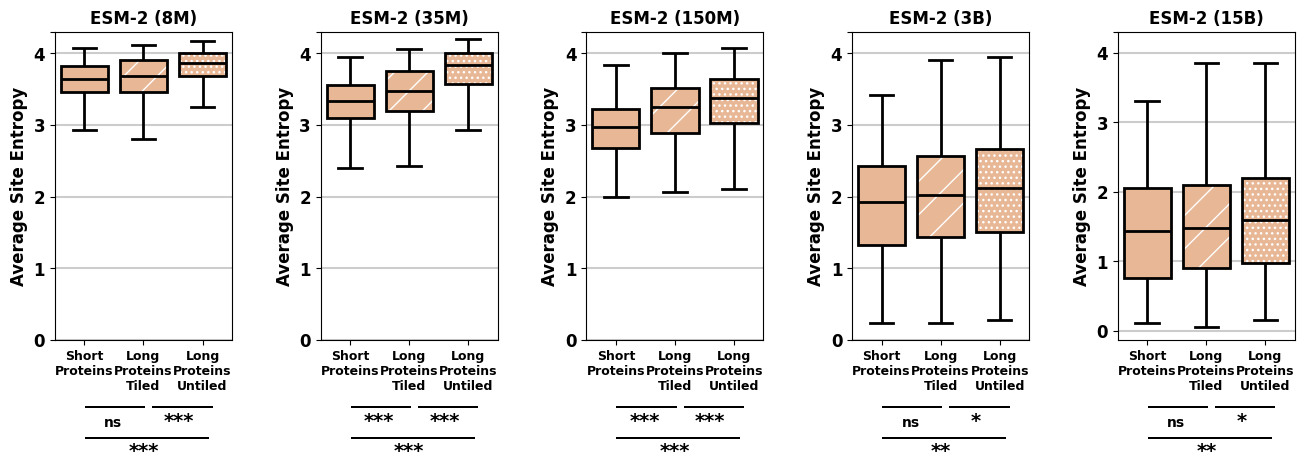

In [52]:
fig, axes = plt.subplots(1,5,figsize = (16,4))
fig.subplots_adjust(wspace = 0.5)



for i, m in enumerate(["esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2", "esm_2_15B"]):
    print("###############", m, "############")
    ax = axes[i]
    
    with open(summary_res_path + m + "_4000.json", "r") as f:
        data = json.load(f)
    f.close()

    pos_to_entropy_vals_2000_3000 = {}
    pos_to_correct_2000_3000 = {}

    pos_to_entropy_vals_over_3000 = {}
    pos_to_correct_over_3000 = {}

    rotary_gene_ent_2000_3000 = []
    rotary_gene_ent_over_3000 = []

    for k, v in data.items():
        if (v["gene_length"] < 3000) and (v["gene_length"] >= 2000):
            pos_ent_list = list(v["positional_entropy"].values())
            rotary_gene_ent_2000_3000.append(np.mean(pos_ent_list))

        if v["gene_length"] >= 3000:
            pos_ent_list = list(v["positional_entropy"].values())
            rotary_gene_ent_over_3000.append(np.mean(pos_ent_list))


    long_protein_json_path = home_path + "clinvar/nlp_review_misclassification/g_results_all/weighted_entropies_" + m + ".json"

    with open(long_protein_json_path, "r") as f1:
        long_protein_data = json.load(f1)
    f1.close()


    tiled_long_protein_average_ent = []

    for gene in data.keys():
        ent_vals = long_protein_data[gene]["weighted_entropies"]
        tiled_long_protein_average_ent.append(np.mean(list(ent_vals.values())))


    with open("./gene_summary_average_entropy/" + m + ".json", "r") as f:
        gene_data = json.load(f)
    f.close()

    control_short_average_ent =  list(gene_data["control_short"].values())

    data = [
        control_short_average_ent,
        tiled_long_protein_average_ent,
        rotary_gene_ent_2000_3000 + rotary_gene_ent_over_3000
    ]
    
    for lst in data:
        print("mean ", np.mean(lst))
    
    sns.boxplot(
        data, 
        showfliers = False, 
        ax = ax,
        palette = {
            0 : "#f5b489",
            1: "#f5b489",
            2 : "#f5b489"
        },
        boxprops = {"edgecolor" : "black", "linewidth": 2},
        medianprops = {"color" : "black", "linewidth": 2},
        whiskerprops = {"color" : "black", "linewidth": 2},
        capprops = {"color" : "black", "linewidth": 2}, 
        zorder = 100
    )
    ax.set_yticks([0,1,2,3, 4, 4.3])
    ax.set_yticklabels(["0", "1","2","3","4", ""], fontweight = "bold", fontsize = 12)
    
    
    for y_val in ax.get_yticks():
        ax.axhline(y = y_val, color = "black", alpha = 0.2, zorder = 1)
    
    ax.set_ylabel("Average Site Entropy", fontweight = "bold", fontsize = 12)
    ax.set_title(model_to_display_name[m], fontweight = "bold")

    ax.set_xticklabels(["Short\nProteins", "Long\nProteins\nTiled", "Long\nProteins\nUntiled"], fontsize = 9, fontweight = "bold")

    hatch_list = ["", "/", "..."]
    c_list = ["white", "white", "white"]
    patches = ax.patches
    for i, (patch, hatch) in enumerate(zip(patches, hatch_list)):
        patch.set_hatch(hatch)
        patch._hatch_color = mcolors.to_rgba(c_list[i])


    _, p1 = scipy.stats.mannwhitneyu(data[0], data[1], alternative = "less")
    stars_1 = p_val_to_stars(p1)
    fs1 = 10 if stars_1 == "ns" else 14
    print(p1)

    ax.text(0.33, -0.28, stars_1, fontsize = fs1, fontweight = "bold", transform = ax.transAxes, horizontalalignment="center")
    rect = mpatches.Rectangle((0.17, -0.22), 0.34, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)

    ###########################
    rect = mpatches.Rectangle((0.55, -0.22), 0.34, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)

    _, p2 = scipy.stats.mannwhitneyu(data[1], data[2], alternative = "less")
    stars_2 = p_val_to_stars(p2)
    fs2 = 10 if stars_2 == "ns" else 14
    print(p2)

    ax.text(0.7, -0.28, stars_2, fontsize = fs2, fontweight = "bold", transform = ax.transAxes, horizontalalignment="center")
    ###########################
    rect = mpatches.Rectangle((0.17, -0.32), 0.7, 0.005, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)

    _, p3 = scipy.stats.mannwhitneyu(data[0], data[2], alternative = "less")
    stars_3 = p_val_to_stars(p3)
    fs3 = 10 if stars_3 == "ns" else 14
    print(p3)

    ax.text(0.5, -0.38, stars_3, fontsize = fs3, fontweight = "bold", transform = ax.transAxes, horizontalalignment="center")

